## Milestone 2

In [2]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
data = pd.read_csv("airline_preprocessed.csv",low_memory=False)
data.sample(20)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ROUTE,FLIGHT_DATE,SCHEDULED_DEPARTURE_DT,DEPARTURE_TIME_DT,SCHEDULED_ARRIVAL_DT,ARRIVAL_TIME_DT
2722925,2015,6,21,Sunday,WN,PVD,BWI,-1.0,14.0,738.0,...,0.0,0.0,0.0,0.0,PVD_BWI,2015-06-21,2015-06-21 07:25:00,2015-06-21 07:24:00,2015-06-21 08:45:00,2015-06-21 08:38:00
4071016,2015,9,10,Thursday,OO,SBN,DTW,-3.0,16.0,1813.0,...,0.0,0.0,0.0,0.0,SBN_DTW,2015-09-10,2015-09-10 18:00:00,2015-09-10 17:57:00,2015-09-10 19:04:00,2015-09-10 18:59:00
2443414,2015,6,4,Thursday,UA,SFO,LAX,18.0,11.0,1239.0,...,0.0,0.0,0.0,0.0,SFO_LAX,2015-06-04,2015-06-04 12:10:00,2015-06-04 12:28:00,2015-06-04 13:43:00,2015-06-04 13:47:00
1177063,2015,3,18,Wednesday,WN,ALB,TPA,-1.0,7.0,751.0,...,0.0,0.0,0.0,0.0,ALB_TPA,2015-03-18,2015-03-18 07:45:00,2015-03-18 07:44:00,2015-03-18 11:00:00,2015-03-18 10:41:00
759280,2015,2,19,Thursday,EV,DTW,PWM,-2.0,22.0,2059.0,...,0.0,0.0,0.0,0.0,DTW_PWM,2015-02-19,2015-02-19 20:39:00,2015-02-19 20:37:00,2015-02-19 22:33:00,2015-02-19 22:33:00
1347026,2015,3,28,Saturday,WN,MDW,DEN,0.0,9.0,1334.0,...,0.0,0.0,0.0,0.0,MDW_DEN,2015-03-28,2015-03-28 13:25:00,2015-03-28 13:25:00,2015-03-28 14:55:00,2015-03-28 14:44:00
1762754,2015,4,23,Thursday,WN,BNA,DEN,-6.0,14.0,858.0,...,0.0,0.0,0.0,0.0,BNA_DEN,2015-04-23,2015-04-23 08:50:00,2015-04-23 08:44:00,2015-04-23 10:40:00,2015-04-23 10:49:00
535647,2015,2,5,Thursday,US,LGA,BOS,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,LGA_BOS,2015-02-05,2015-02-05 11:00:00,NaN,2015-02-05 12:08:00,NaN
2064607,2015,5,12,Tuesday,AS,FAI,SEA,-7.0,15.0,148.0,...,0.0,0.0,0.0,0.0,FAI_SEA,2015-05-12,2015-05-12 01:40:00,2015-05-12 01:33:00,2015-05-12 06:05:00,2015-05-12 06:18:00
3640551,2015,8,14,Friday,AA,PHX,IAH,-2.0,12.0,1615.0,...,0.0,0.0,0.0,0.0,PHX_IAH,2015-08-14,2015-08-14 16:05:00,2015-08-14 16:03:00,2015-08-14 20:42:00,2015-08-14 21:02:00


## Top Airlines By Flight Volume 

C:\Users\hp\AppData\Local\Temp\ipykernel_6848\1698048693.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


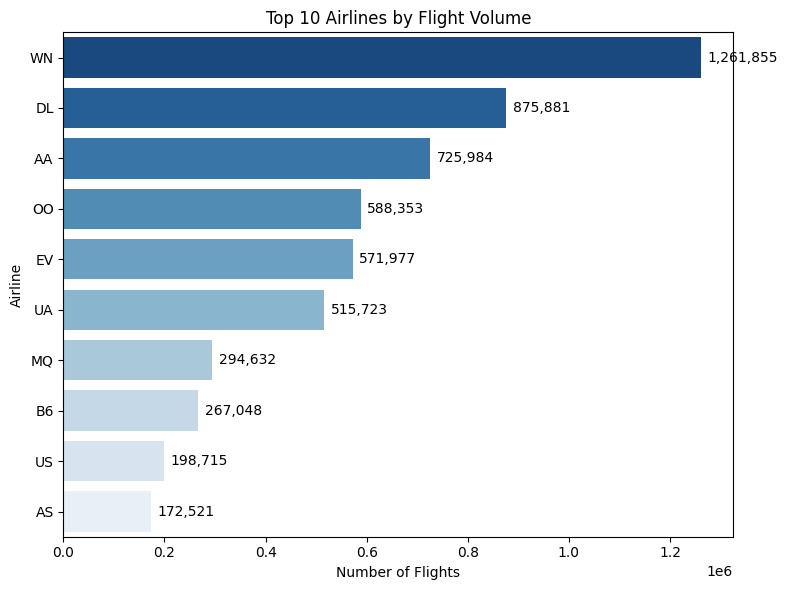

In [4]:

top_airlines = data['AIRLINE'].value_counts().head(10)

plt.figure(figsize=(8,6))
ax = sns.barplot(
    x=top_airlines.values,
    y=top_airlines.index,
    palette="Blues_r"
)

# Add value labels
for i, v in enumerate(top_airlines.values):
    ax.text(
        v + 0.01 * max(top_airlines.values), i,f"{v:,}",va='center'
    )

plt.title("Top 10 Airlines by Flight Volume")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

plt.tight_layout()
plt.show()

## Busiest Months

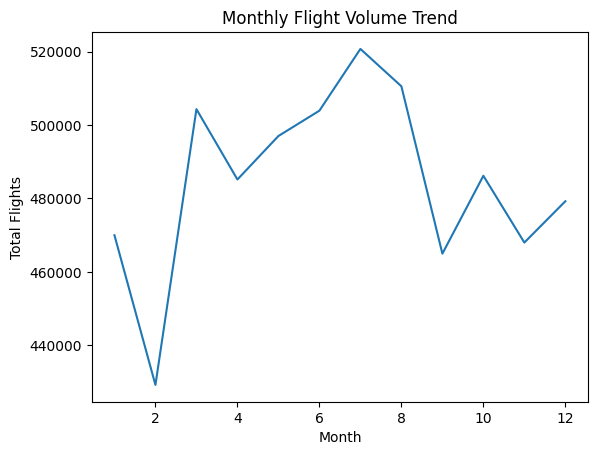

In [6]:
monthly_flights = data.groupby('MONTH').size()

plt.figure()
monthly_flights.plot()
plt.title("Monthly Flight Volume Trend")
plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.show()

## Route Congestion vs Delay

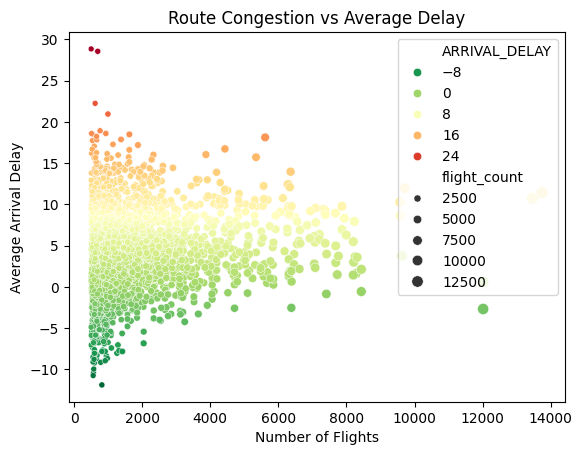

In [39]:
route_stats = data.groupby('ROUTE').agg({
    'ARRIVAL_DELAY': 'mean',
    'ROUTE': 'count'
}).rename(columns={'ROUTE':'flight_count'})

plt.figure()
route_stats = route_stats[route_stats['flight_count'] > 500]
sns.scatterplot(data=route_stats, x='flight_count', y='ARRIVAL_DELAY',
                size='flight_count', hue='ARRIVAL_DELAY', palette='RdYlGn_r')
#sns.scatterplot(data=route_stats,x='flight_count',y='ARRIVAL_DELAY')
plt.title("Route Congestion vs Average Delay")
plt.xlabel("Number of Flights")
plt.ylabel("Average Arrival Delay")
plt.show()

## Delay Distribution by Airline

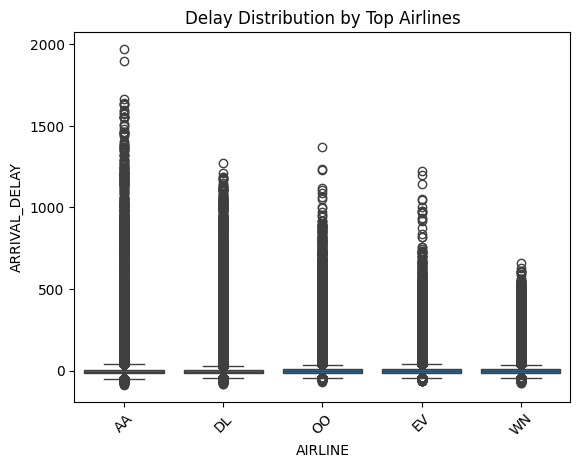

In [11]:
top5 = data['AIRLINE'].value_counts().head(5).index
filtered = data[data['AIRLINE'].isin(top5)]

plt.figure()
sns.boxplot(
    data=filtered,
    x='AIRLINE',
    y='ARRIVAL_DELAY'
)
plt.title("Delay Distribution by Top Airlines")
plt.xticks(rotation=45)
plt.show()

## Busiest Route

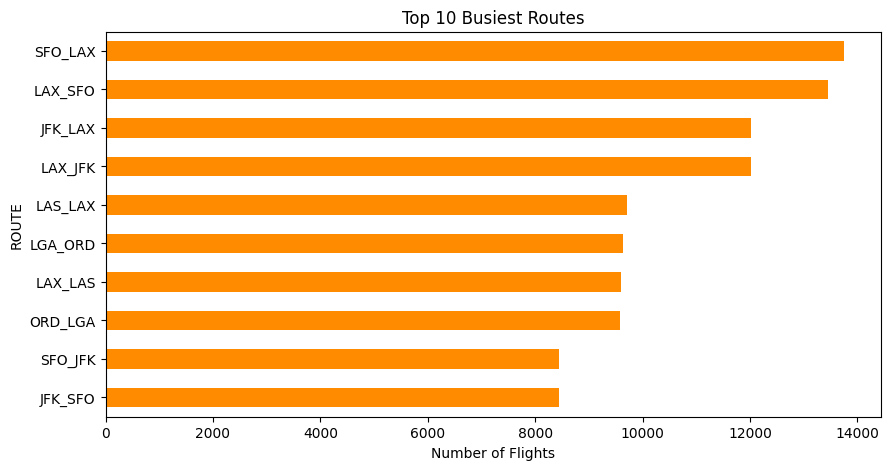

Observation: SFO-LAX is the busiest corridor — short-haul high-frequency routes dominate the top 10.


In [47]:
top_routes = data['ROUTE'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_routes.plot(kind='barh', color='darkorange')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.gca().invert_yaxis()
plt.show()
print("Observation: SFO-LAX is the busiest corridor — short-haul high-frequency routes dominate the top 10.")

## Delay Analysis

## Delay Cause Comparison

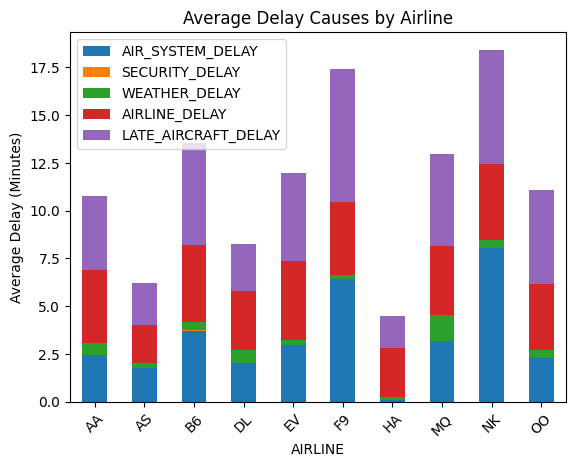

In [14]:
delay_causes = data.groupby('AIRLINE')[[
    'AIR_SYSTEM_DELAY','SECURITY_DELAY',
    'WEATHER_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY'
]].mean().head(10)

delay_causes.plot(kind='bar', stacked=True)
plt.title("Average Delay Causes by Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.show()

## Delay Cause Breakdown by Airline

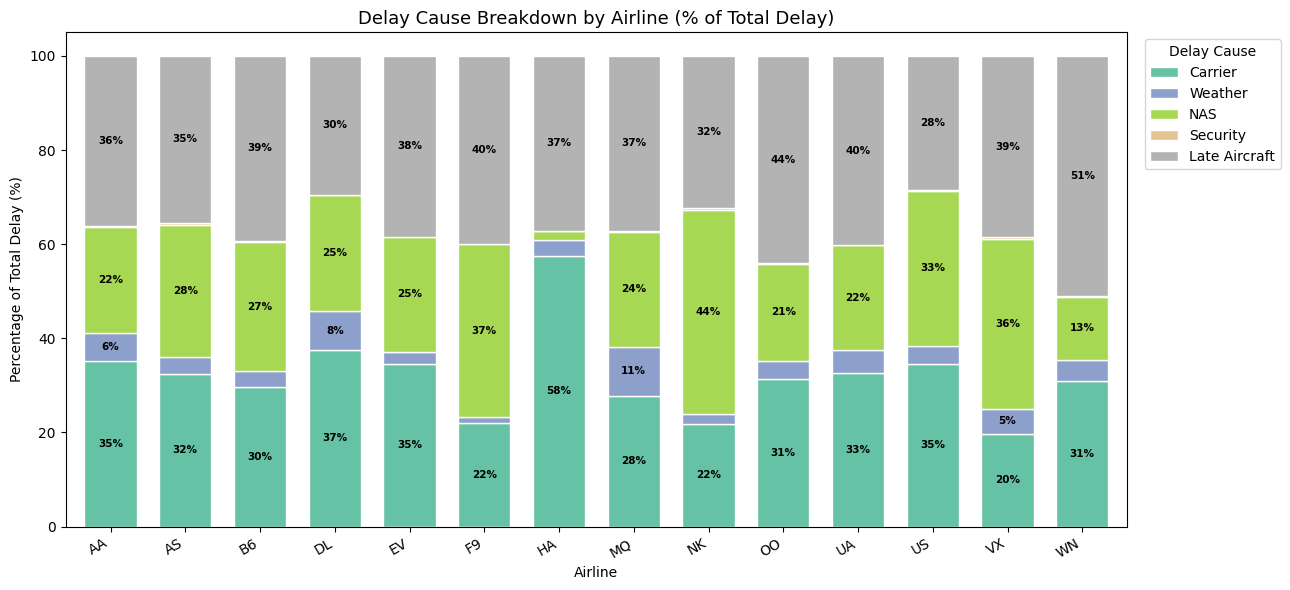

Observation: Late Aircraft and Carrier delays together account for 70-80% of total delay across most airlines.
Security delay is negligible (<1%) for all carriers.


In [55]:
import matplotlib.pyplot as plt
import pandas as pd

cause_cols = ['AIRLINE_DELAY','WEATHER_DELAY','AIR_SYSTEM_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
cause_labels = ['Carrier','Weather','NAS','Security','Late Aircraft']

# Calculate mean delay causes
delay_causes = data[data['ARRIVAL_DELAY'] > 0].groupby('AIRLINE')[cause_cols].mean()
delay_causes.columns = cause_labels

# Convert to percentage of total for each airline
delay_pct = delay_causes.div(delay_causes.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
delay_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', width=0.7)

# Add percentage labels inside each bar segment
for bar_stack in ax.containers:
    for bar in bar_stack:
        height = bar.get_height()
        if height > 5:  # only label if segment is wide enough to read
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{height:.0f}%',
                ha='center', va='center',
                fontsize=7.5, color='black', fontweight='bold'
            )

ax.set_title("Delay Cause Breakdown by Airline (% of Total Delay)", fontsize=13)
ax.set_ylabel("Percentage of Total Delay (%)")
ax.set_xlabel("Airline")
ax.set_ylim(0, 105)
ax.legend(title="Delay Cause", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Observation: Late Aircraft and Carrier delays together account for 70-80% of total delay across most airlines.")
print("Security delay is negligible (<1%) for all carriers.")

## Weather Delay Seasonal Trend

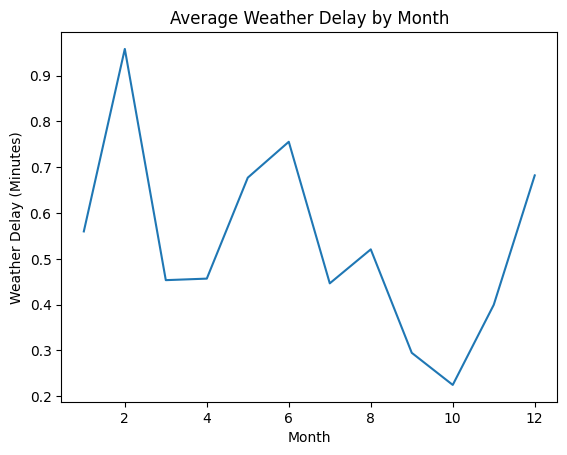

In [16]:
weather_month = data.groupby('MONTH')['WEATHER_DELAY'].mean()

plt.figure()
weather_month.plot()
plt.title("Average Weather Delay by Month")
plt.xlabel("Month")
plt.ylabel("Weather Delay (Minutes)")
plt.show()

## Distribution of Arrival Delay

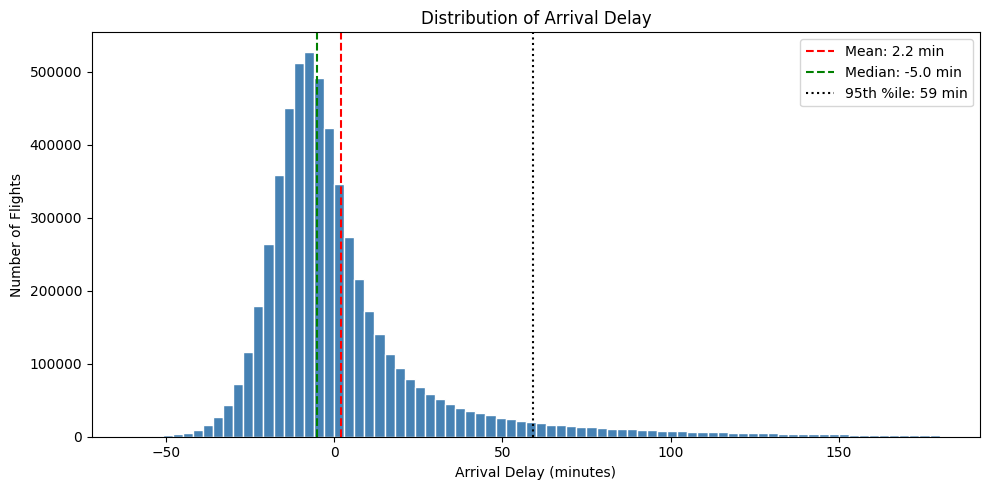

Mean:       2.2 min
Median:     -5.0 min
Early (<0): 61.8%
On-Time (0-15 min):    21.0%
Severely delayed (>60): 4.8%


In [51]:
import matplotlib.pyplot as plt

delay = data['ARRIVAL_DELAY'].dropna()
delay = delay[(delay >= -60) & (delay <= 180)]

plt.figure(figsize=(10, 5))
plt.hist(delay, bins=80, color='steelblue', edgecolor='white')

plt.axvline(delay.mean(),            color='red',   linestyle='--', label=f'Mean: {delay.mean():.1f} min')
plt.axvline(delay.median(),          color='green', linestyle='--', label=f'Median: {delay.median():.1f} min')
plt.axvline(delay.quantile(0.95),    color='black', linestyle=':',  label=f'95th %ile: {delay.quantile(0.95):.0f} min')

plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean:       {delay.mean():.1f} min")
print(f"Median:     {delay.median():.1f} min")
print(f"Early (<0): {(delay < 0).mean()*100:.1f}%")
print(f"On-Time (0-15 min):    {((delay>=0)&(delay<=15)).mean()*100:.1f}%")
print(f"Severely delayed (>60): {(delay > 60).mean()*100:.1f}%")

## Delay Severity Composition by Airline

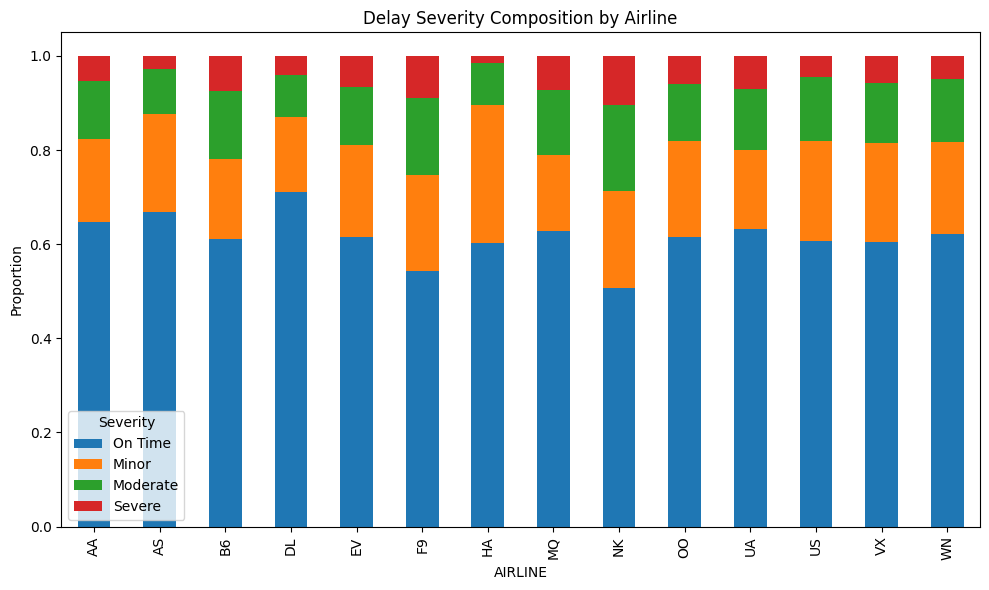

In [20]:
data['delay_severity'] = pd.cut(
    data['ARRIVAL_DELAY'],
    bins=[-1000, 0, 15, 60, 10000],
    labels=['On Time', 'Minor', 'Moderate', 'Severe']
)

severity = (
    data.groupby('AIRLINE')['delay_severity']
    .value_counts(normalize=True)
    .unstack()
)

severity.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Delay Severity Composition by Airline")
plt.ylabel("Proportion")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

## Departure Delay Analysis

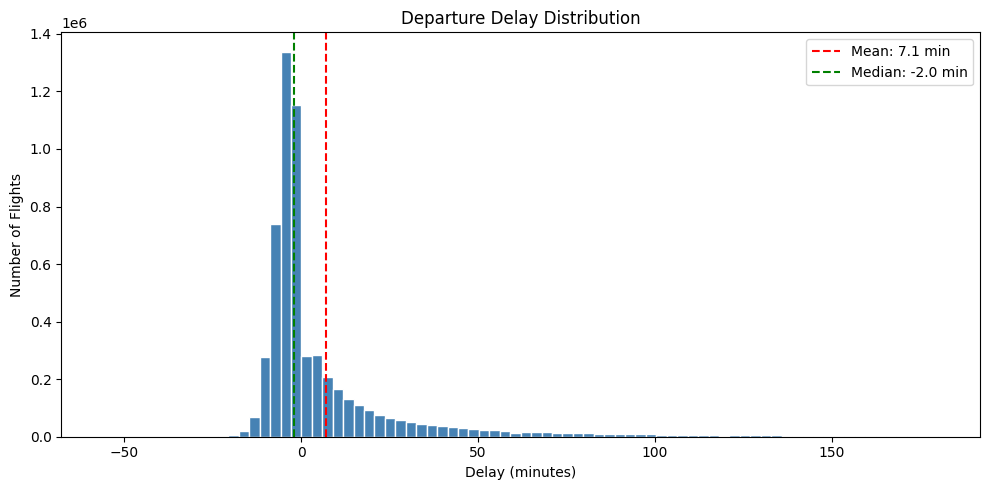

Observation: Most flights are on time or early. Mean (7.1) >> Median (-2.0) shows extreme delays pull the average up.


In [42]:
delay = data['DEPARTURE_DELAY'].dropna()
delay = delay[(delay >= -60) & (delay <= 180)]

plt.figure(figsize=(10,5))
plt.hist(delay, bins=80, color='steelblue', edgecolor='white')
plt.axvline(delay.mean(),   color='red',   linestyle='--', label=f'Mean: {delay.mean():.1f} min')
plt.axvline(delay.median(), color='green', linestyle='--', label=f'Median: {delay.median():.1f} min')
plt.title("Departure Delay Distribution")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Flights")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Observation: Most flights are on time or early. Mean ({delay.mean():.1f}) >> Median ({delay.median():.1f}) shows extreme delays pull the average up.")

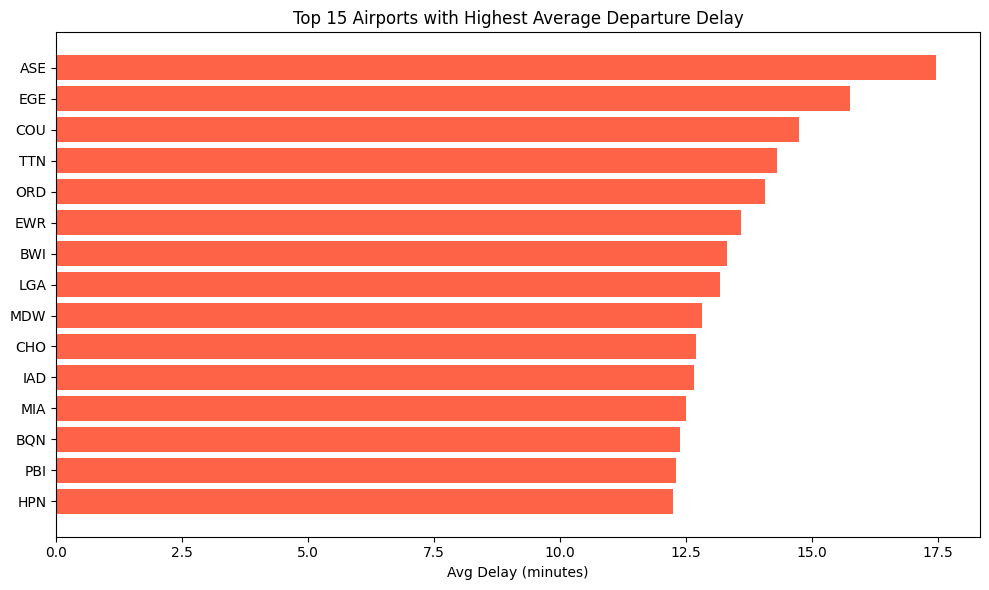

Observation: Mid-size congested airports show worse delays than major hubs which have better scheduling buffers.


In [49]:
airport_delay = data[data['CANCELLED']==0].groupby('ORIGIN_AIRPORT').agg(
    avg_delay  = ('DEPARTURE_DELAY','mean'),
    flight_count = ('DEPARTURE_DELAY','count')
).reset_index()


airport_delay = airport_delay[airport_delay['flight_count'] > 1000]
top15 = airport_delay.nlargest(15, 'avg_delay')

plt.figure(figsize=(10,6))
plt.barh(top15['ORIGIN_AIRPORT'], top15['avg_delay'], color='tomato')
plt.title("Top 15 Airports with Highest Average Departure Delay")
plt.xlabel("Avg Delay (minutes)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Observation: Mid-size congested airports show worse delays than major hubs which have better scheduling buffers.")